In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
TAXONOMY_PATH = DATA_DIR / "label_taxonomy.csv"

In [13]:
required_paths = [TRAIN_PATH, TEST_PATH, TAXONOMY_PATH]
missing_files = [str(p) for p in required_paths if not p.exists()]

if missing_files:
    print("Missing required files:")
    for file in missing_files:
        print("-", file)
    raise FileNotFoundError(
        "Please add the dataset CSV files to the data folder and rerun this cell."
    )

train_df = pd.read_csv(TRAIN_PATH, sep="\t")
test_df = pd.read_csv(TEST_PATH, sep="\t")
taxonomy_df = pd.read_csv(TAXONOMY_PATH, sep="\t")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("taxonomy shape:", taxonomy_df.shape)

display(train_df.head())
display(taxonomy_df.head())

train shape: (139156, 3)
test shape: (34790, 2)
taxonomy shape: (39, 2)


,id,abstract,label_id
0,95829,"Project-based learning plays a crucial role in computing education. However, its open-ended nature makes tracking project development and assessing success ...",14
1,73195,Edge computing is a distributed computing paradigm that brings computation\nand data storage closer to the user's geographical location to improve respons...,10
2,22319,"In today's computing environment, where Artificial Intelligence (AI) and data\nprocessing are moving toward the Internet of Things (IoT) and Edge computin...",3
3,76837,"Diffusion pipelines, renowned for their powerful visual generation capabilities, have seen widespread adoption in generative vision tasks (e.g., text-to-ima...",10
4,159150,Convolutional neural networks (CNNs) are emerging as powerful tools for image\nprocessing in important commercial applications. We focus on the important\...,30


,label_id,category
0,0,cs.DS
1,1,cs.CC
2,2,cs.CR
3,3,cs.PF
4,4,cs.CV


,label_id,count,percent,category
2,2,8000,5.75,cs.CR
5,5,8000,5.75,cs.LG
4,4,8000,5.75,cs.CV
6,6,8000,5.75,cs.SE
18,18,8000,5.75,cs.CL
12,12,8000,5.75,cs.NI
8,8,8000,5.75,cs.AI
23,23,8000,5.75,cs.RO
0,0,7773,5.59,cs.DS
14,14,7635,5.49,cs.HC


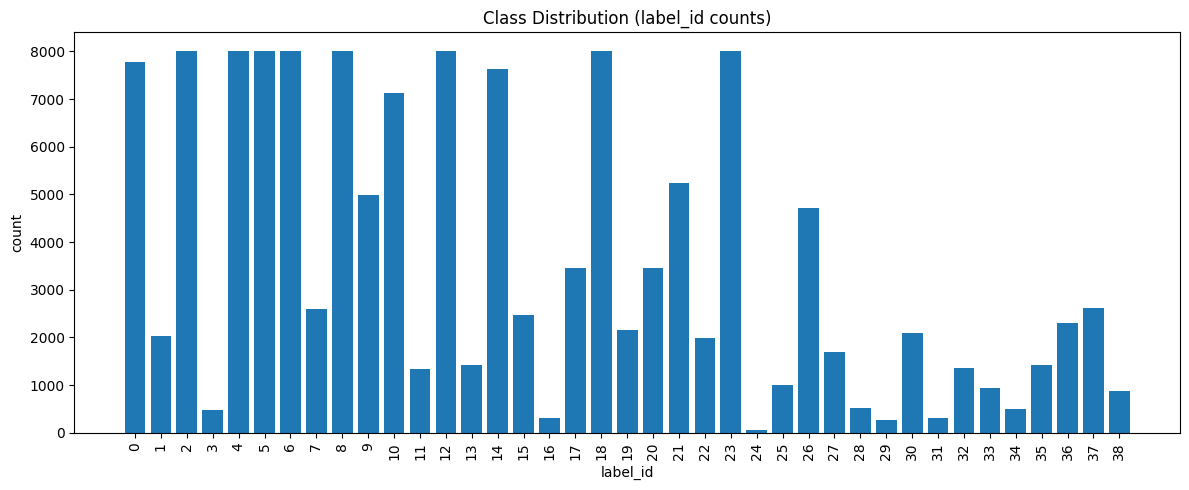

In [14]:
label_counts = train_df["label_id"].value_counts().sort_index()
label_share = (label_counts / label_counts.sum()).mul(100).round(2)

distribution_df = (
    pd.DataFrame({"count": label_counts, "percent": label_share})
    .reset_index()
    .rename(columns={"index": "label_id"})
)

distribution_named_df = distribution_df.merge(taxonomy_df, on="label_id", how="left")
display(distribution_named_df.sort_values("count", ascending=False))

plt.figure(figsize=(12, 5))
plt.bar(distribution_df["label_id"].astype(str), distribution_df["count"])
plt.title("Class Distribution (label_id counts)")
plt.xlabel("label_id")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
abstract_char_len,139156.0,1156.473454,389.218238,26.0,889.0,1154.0,1431.0,3857.0
abstract_word_len,139156.0,166.133404,55.630223,4.0,128.0,165.0,203.0,588.0


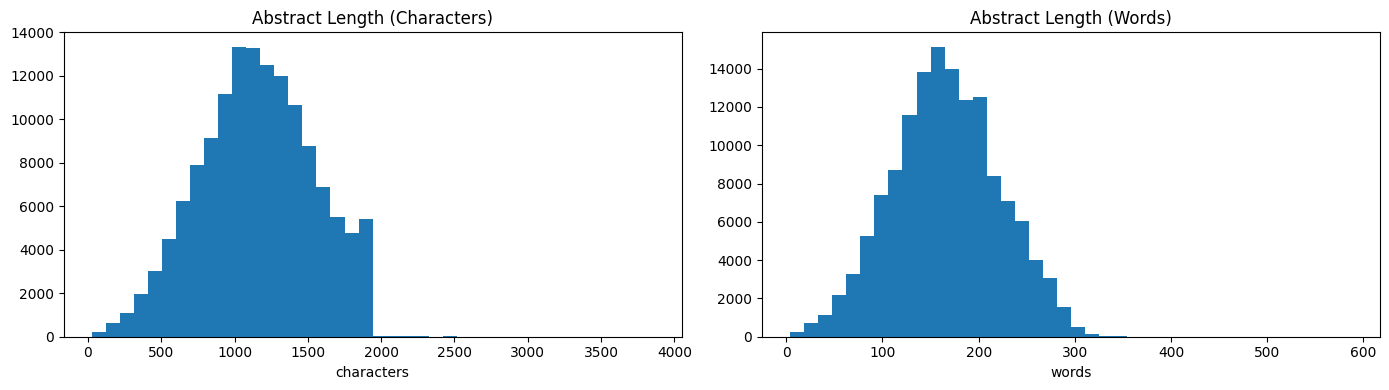

In [15]:
train_df["abstract"] = train_df["abstract"].fillna("")

train_df["abstract_char_len"] = train_df["abstract"].str.len()
train_df["abstract_word_len"] = train_df["abstract"].str.split().str.len()

display(train_df[["abstract_char_len", "abstract_word_len"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df["abstract_char_len"], bins=40)
axes[0].set_title("Abstract Length (Characters)")
axes[0].set_xlabel("characters")

axes[1].hist(train_df["abstract_word_len"], bins=40)
axes[1].set_title("Abstract Length (Words)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.show()

In [16]:
sample_df = (
    train_df[["id", "label_id", "abstract"]]
    .sample(8, random_state=42)
    .merge(taxonomy_df, on="label_id", how="left")
)
display(sample_df[["id", "label_id", "category", "abstract"]])

,id,label_id,category,abstract
0,39289,5,cs.LG,Machine learning enables extracting clinical insights from large temporal\ndatasets. The applications of such machine learning models include identifying\...
1,147966,23,cs.RO,"Cooperative autonomous driving, which extends vehicle autonomy by enabling real-time collaboration between vehicles and smart roadside infrastructure, remai..."
2,163621,33,cs.MM,To hide a binary pattern in the palette image a steganographic scheme with\nblind detection is considered. The embedding algorithm uses the Lehmer code by...
3,146962,23,cs.RO,Cooperative Unmanned Aerial Systems (UASs) in GPS-denied environments demand\nan accurate pose-localization system to ensure efficient operation. In this\...
4,162589,32,cs.GR,"Transfer learning of diffusion models to smaller target domains is challenging, as naively fine-tuning the model often results in poor generalization. Test-..."
5,4753,0,cs.DS,Shortest Remaining Processing Time (SRPT) is a well known preemptive\nscheduling algorithm for uniprocessor and multiprocessor systems. SRPT finds\napplic...
6,105781,15,cs.NE,"The Vehicle Routing Problem with Simultaneous Pickup-Delivery and Time\nWindows (VRPSPDTW) has attracted much research interest in the last decade, due\nt..."
7,19381,2,cs.CR,"In this paper we show how two (or more) airgapped computers in the same room,\nequipped with passive speakers, headphones, or earphones can covertly excha..."
